In [12]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import random

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, BayesianRidge
from sklearn.metrics import confusion_matrix, classification_report, f1_score,balanced_accuracy_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

from dmba import regressionSummary, adjusted_r2_score, AIC_score, BIC_score

from keras import Input

np.random.seed(1)
tf.random.set_seed(1)
random.seed(1)

In [13]:
file_path = r"C:/Users/deanc/Documents/Datasets/FinancialData/custom_financial_classification/custom_financial_classification_dataset.csv"  # Update the path as needed
financial_classification = pd.read_csv(file_path)
financial_classification.head()
financial_risk_level = financial_classification['Risk_Level'].value_counts() #How many total risk levels are there?
print(financial_risk_level)

Risk_Level
0    7785
2    1692
1     523
Name: count, dtype: int64


In [14]:
financial_classification.head()

,Annual_Income,Credit_Score,Age,Loan_Amount,Loan_Term,Employment_Status,Stock_Portfolio_Value,Crypto_Investments,Charitable_Donations,Has_Multiple_Loans,Risk_Level
0,87417.221393,505.502450,39,55462.060216,24,Unemployed,145526.208009,10124.484630,11124.220405,1,2
1,191128.575154,483.101653,19,34638.676477,24,Employed,331719.083372,1910.917152,5167.670973,0,0
2,151758.909526,396.884652,21,75231.956980,48,Self-Employed,196354.905349,3149.109906,15221.690384,0,2
3,127758.527155,633.996669,62,67890.389187,36,Employed,486256.351748,22669.462066,16283.977615,0,0
4,48083.355280,562.143288,30,97168.499769,36,Self-Employed,202480.459235,20911.729108,10152.129556,1,2


In [15]:
financial_classification.shape

(10000, 11)

In [16]:
financial_classification.dtypes

Annual_Income            float64
Credit_Score             float64
Age                        int64
Loan_Amount              float64
Loan_Term                  int64
Employment_Status         object
Stock_Portfolio_Value    float64
Crypto_Investments       float64
Charitable_Donations     float64
Has_Multiple_Loans         int64
Risk_Level                 int64
dtype: object

In [17]:
predictors = [
    "Annual_Income",
    "Credit_Score",
    "Age",
    "Loan_Amount",
    "Loan_Term",
    #"Stock_Portfolio_Value",
    #"Crypto_Investments",
    "Has_Multiple_Loans",
]
outcome = "Risk_Level"

In [18]:
X = financial_classification[predictors]
y = financial_classification[outcome]
train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=0.4, random_state=1, stratify=y)


In [19]:
#feedforward neural network(Multilayer Perceptron) using Keras Sequential API
#Input -> Dense(16) -> Dense(16) -> Dense(8) -> Dense(1)
#Each layer is:
"""
z = Wx + b
W = weights
b = bias
x = input
z = activation (ReLu here)
"""

'\nz = Wx + b\nW = weights\nb = bias\nx = input\nz = activation (ReLu here)\n'

In [20]:

model = keras.Sequential([ #Build model where layers are stacked on top of each other in sequential order
    Input(shape=(train_X.shape[1],)), #Each data point has train_X.shape[1] features (6 features in predictors to start so x = [x1,x2,x3,x4,x5,x6]) shape=(6,), one vector 0f 6 features
    layers.Dense(16, activation="relu"), #16 neurons and each neuron receives all 6 inputs
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(3, activation="softmax")  # Regression output where we can not have negative layers (Try different layers )
])


In [21]:
model.compile(optimizer="adam", loss='sparse_categorical_crossentropy', metrics=['accuracy'])

scaler = StandardScaler()
train_X = scaler.fit_transform(train_X) #fit on train
valid_X = scaler.transform(valid_X) #Only transform on valid

classes = np.unique(train_y)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_y)
class_weight = dict(zip(classes, weights))

# Fit the model
history = model.fit( #history stores loss per epoch and MAE per epoch We can even plot the samples to track data
    train_X, 
    train_y,
    validation_data=(valid_X,valid_y),
    epochs=15, #An epoch = one full pass through the training set. So your model see the entire dataset 15 times. More epochs = more learning opportunities.
    batch_size=32, #Instead of updating weights, Takes 32 samples, computes gradients, updates weights and moves to next 32.
    class_weight=class_weight,
    verbose=1 #controls how much training information gets printed on the screen
)

# Make predictions
predictions = model.predict(valid_X) #Takes validation inputs, runs forward pass, outputs predicited values.
predicted_classes = np.argmax(predictions, axis=1)
cm = confusion_matrix(valid_y,predicted_classes)
cm

Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.5462 - loss: 1.0001 - val_accuracy: 0.6725 - val_loss: 0.8208
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6418 - loss: 0.7606 - val_accuracy: 0.6220 - val_loss: 0.8066
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6363 - loss: 0.6741 - val_accuracy: 0.6480 - val_loss: 0.7479
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6508 - loss: 0.6358 - val_accuracy: 0.6693 - val_loss: 0.7118
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6710 - loss: 0.6132 - val_accuracy: 0.6850 - val_loss: 0.6863
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6863 - loss: 0.5966 - val_accuracy: 0.6980 - val_loss: 0.6711
Epoch 7/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6995 - loss: 0.5848 - val_accuracy: 0.7040 - val_loss: 0.6633
Epoch 8/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7073 - loss: 0.5760 - val_accuracy: 0

array([[2129,  602,  383],
       [  37,  150,   22],
       [  12,   12,  653]])

In [22]:
class_weight1 = {0: 1.0, 1: 3., 2: 1.5}
class_weight2 = {0:1.0, 1:2.0, 2:1.5}
class_weight3 = {0:1.0, 1:2.5, 2:1.5}
class_weight4 = {0:1.0, 1:3.5, 2:1.5}

In [97]:
def build_model(input_dim):
    
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(3, activation="softmax")
    ])
    
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model
model1 = build_model(train_X.shape[1])

def run_experiment(
    model,
    train_X,
    train_y,
    valid_X,
    valid_y,
    class_weight=None,
    epochs=20,
    batch_size=32
):
    
    history = model.fit(
        train_X,
        train_y,
        validation_data=(valid_X, valid_y),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weight,
        verbose=0
    )
    
    predictions = model.predict(valid_X)
    pred_classes = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(valid_y, pred_classes)
    macro_f1 = f1_score(valid_y, pred_classes, average="macro")
    balanced_acc = balanced_accuracy_score(valid_y, pred_classes)
    
    print("Accuracy:", round(accuracy,4))
    print("Macro F1:", round(macro_f1, 4))
    print("Balanced Accuracy:", round(balanced_acc, 4))

    pred = model1.predict(valid_X)
    pred_classes = pred.argmax(axis=1)
    print("\nConfusion Matrix:\n",confusion_matrix(valid_y, pred_classes))
    print("\nClassification Report:\n", classification_report(valid_y, pred_classes, digits=3))
    
    return {
        "history": history,
        "accuracy":accuracy,
        "macro_f1": macro_f1,
        "balanced_accuracy": balanced_acc,
        "valid_y": valid_y,
        "pred_classes": pred_classes
    }

experiment1 = run_experiment(model1,train_X,train_y,valid_X,valid_y,class_weight=class_weight1, epochs=20,batch_size=32)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.837
Macro F1: 0.6324
Balanced Accuracy: 0.6677
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Confusion Matrix:
 [[2674  129  311]
 [ 144   45   20]
 [  47    1  629]]

Classification Report:
               precision    recall  f1-score   support

           0      0.933     0.859     0.894      3114
           1      0.257     0.215     0.234       209
           2      0.655     0.929     0.768       677

    accuracy                          0.837      4000
   macro avg      0.615     0.668     0.632      4000
weighted avg      0.851     0.837     0.839      4000



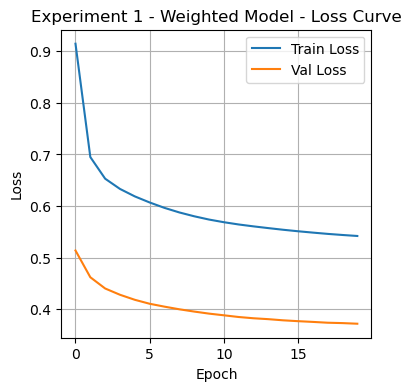

In [98]:
def plot_history(experiment,title,size_w,size_h):

    fig,ax = plt.subplots(figsize=(size_w,size_h))
    ax.grid()
    ax.set_ylabel("Loss")
    ax.set_xlabel("Epoch")
    ax.set_title(title)

    ax.plot(experiment.history['loss'], label='Train Loss')
    ax.plot(experiment.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.show()

plot_history(experiment1['history'],'Experiment 1 - Weighted Model - Loss Curve',4,4)

In [99]:
def plot_confusion_matrix(
    y_true,
    y_pred,
    class_labels=None,
    normalize=False,
    title=None,
    figsize=(6,5),
    cmap="Blues"
):
    
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=figsize)
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f" if normalize else "d",
        cmap=cmap,
        xticklabels=class_labels,
        yticklabels=class_labels,
        cbar=False
    )
    
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    return cm

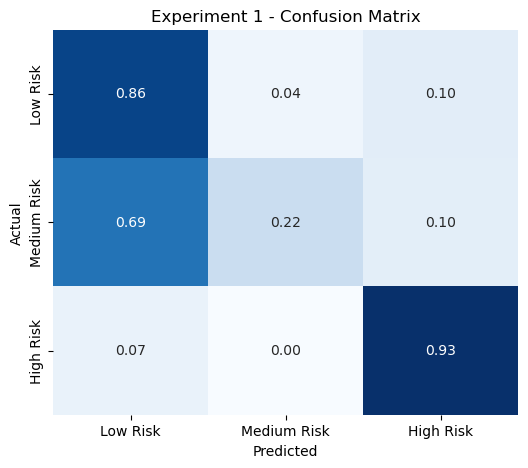

array([[0.85870263, 0.04142582, 0.09987155],
       [0.68899522, 0.215311  , 0.09569378],
       [0.06942393, 0.0014771 , 0.92909897]])

In [100]:
plot_confusion_matrix(
    experiment1['valid_y'],
    experiment1['pred_classes'],
    title = "Experiment 1 - Confusion Matrix",
    class_labels=['Low Risk', 'Medium Risk', 'High Risk'],
    normalize=True
)

In [101]:
experiment2 = run_experiment(model1,train_X,train_y,valid_X,valid_y,class_weight=class_weight2, epochs=20,batch_size=32)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.8482
Macro F1: 0.6064
Balanced Accuracy: 0.6407
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Confusion Matrix:
 [[2733   58  323]
 [ 168   21   20]
 [  38    0  639]]

Classification Report:
               precision    recall  f1-score   support

           0      0.930     0.878     0.903      3114
           1      0.266     0.100     0.146       209
           2      0.651     0.944     0.770       677

    accuracy                          0.848      4000
   macro avg      0.615     0.641     0.606      4000
weighted avg      0.848     0.848     0.841      4000



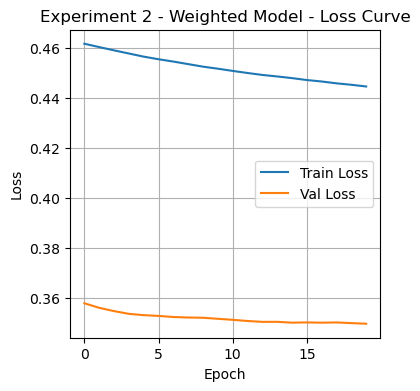

In [102]:
plot_history(experiment2['history'],'Experiment 2 - Weighted Model - Loss Curve',4,4)

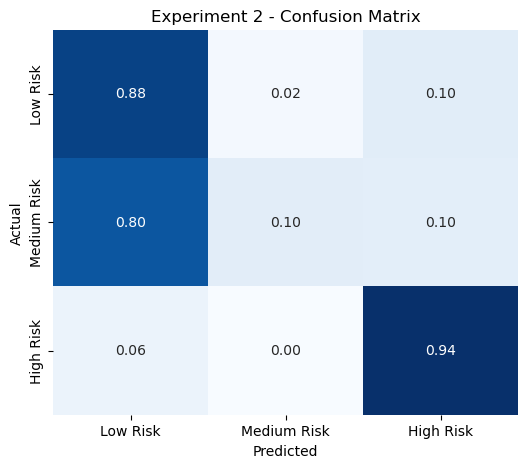

array([[0.87764933, 0.01862556, 0.10372511],
       [0.80382775, 0.10047847, 0.09569378],
       [0.05612999, 0.        , 0.94387001]])

In [103]:
plot_confusion_matrix(
    experiment2['valid_y'],
    experiment2['pred_classes'],
    title='Experiment 2 - Confusion Matrix',
    class_labels=['Low Risk', 'Medium Risk', 'High Risk'],
    normalize=True
)

In [104]:
experiment3 = run_experiment(model1,train_X,train_y,valid_X,valid_y,class_weight=class_weight3, epochs=20,batch_size=32)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.8397
Macro F1: 0.6255
Balanced Accuracy: 0.6635
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Confusion Matrix:
 [[2676  112  326]
 [ 152   37   20]
 [  30    1  646]]

Classification Report:
               precision    recall  f1-score   support

           0      0.936     0.859     0.896      3114
           1      0.247     0.177     0.206       209
           2      0.651     0.954     0.774       677

    accuracy                          0.840      4000
   macro avg      0.611     0.664     0.625      4000
weighted avg      0.852     0.840     0.839      4000



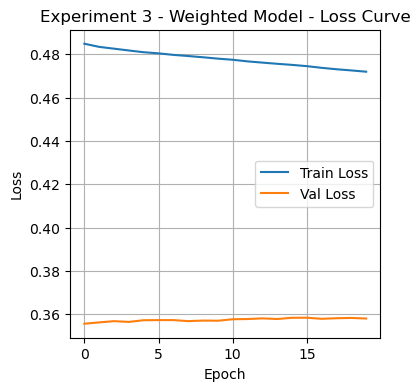

In [105]:
plot_history(experiment3['history'],'Experiment 3 - Weighted Model - Loss Curve',4,4)

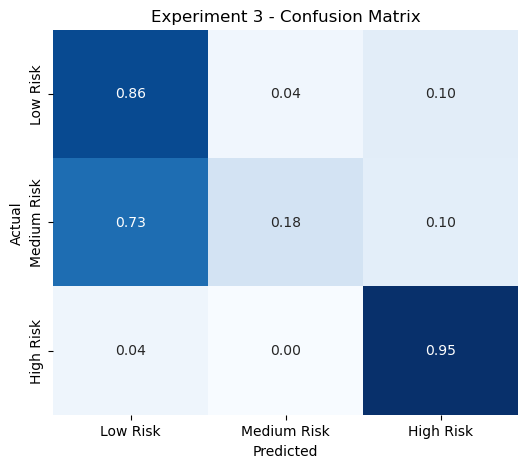

array([[0.85934489, 0.0359666 , 0.1046885 ],
       [0.72727273, 0.17703349, 0.09569378],
       [0.04431315, 0.0014771 , 0.95420975]])

In [106]:
plot_confusion_matrix(
    experiment3['valid_y'],
    experiment3['pred_classes'],
    title='Experiment 3 - Confusion Matrix',
    class_labels=['Low Risk', 'Medium Risk', 'High Risk'],
    normalize=True
)

In [107]:
experiment4 = run_experiment(model1,train_X,train_y,valid_X,valid_y,class_weight=class_weight4, epochs=20,batch_size=32)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.8277
Macro F1: 0.651
Balanced Accuracy: 0.7033
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Confusion Matrix:
 [[2606  181  327]
 [ 119   70   20]
 [  36    6  635]]

Classification Report:
               precision    recall  f1-score   support

           0      0.944     0.837     0.887      3114
           1      0.272     0.335     0.300       209
           2      0.647     0.938     0.766       677

    accuracy                          0.828      4000
   macro avg      0.621     0.703     0.651      4000
weighted avg      0.858     0.828     0.836      4000



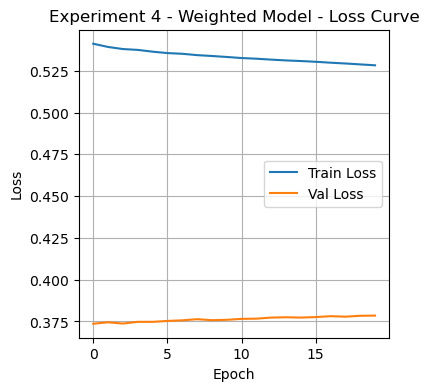

In [108]:
plot_history(experiment4['history'],'Experiment 4 - Weighted Model - Loss Curve',4,4)

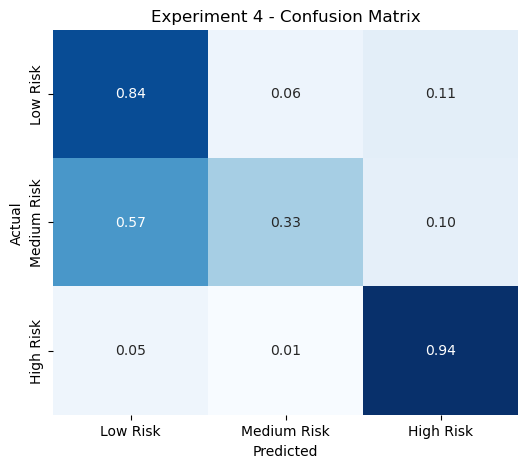

array([[0.83686577, 0.0581246 , 0.10500963],
       [0.56937799, 0.33492823, 0.09569378],
       [0.05317578, 0.00886263, 0.9379616 ]])

In [109]:
plot_confusion_matrix(
    experiment4['valid_y'],
    experiment4['pred_classes'],
    title = 'Experiment 4 - Confusion Matrix',
    class_labels=['Low Risk', 'Medium Risk', 'High Risk'],
    normalize=True
)

Alright! Let's try adding some Regularization to see if we can improve our results! 

In [110]:
def build_model_l2_dropout(input_dim, l2_lambda=1e-4, dropout=0.2):
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(l2_lambda)),
        layers.Dropout(dropout),
        layers.Dense(16, activation="relu", kernel_regularizer=regularizers.l2(l2_lambda)),
        layers.Dropout(dropout),
        layers.Dense(3, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [111]:
model2 = build_model_l2_dropout(train_X.shape[1])

In [112]:
experiment5 = run_experiment(model2,train_X,train_y,valid_X,valid_y,class_weight=class_weight3, epochs=20,batch_size=32)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.8565
Macro F1: 0.5934
Balanced Accuracy: 0.63
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Confusion Matrix:
 [[2606  181  327]
 [ 119   70   20]
 [  36    6  635]]

Classification Report:
               precision    recall  f1-score   support

           0      0.944     0.837     0.887      3114
           1      0.272     0.335     0.300       209
           2      0.647     0.938     0.766       677

    accuracy                          0.828      4000
   macro avg      0.621     0.703     0.651      4000
weighted avg      0.858     0.828     0.836      4000



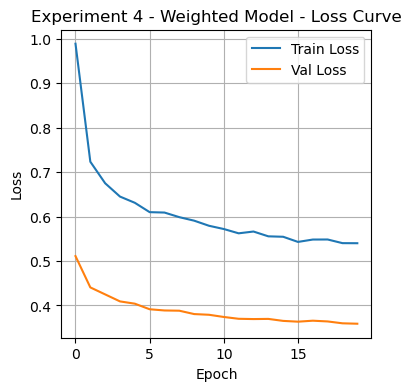

In [113]:
plot_history(experiment5['history'],'Experiment 4 - Weighted Model - Loss Curve',4,4)

In [114]:
experiment6 = run_experiment(model2,train_X,train_y,valid_X,valid_y,class_weight=class_weight1, epochs=20,batch_size=32)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.8445
Macro F1: 0.6308
Balanced Accuracy: 0.6667
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Confusion Matrix:
 [[2606  181  327]
 [ 119   70   20]
 [  36    6  635]]

Classification Report:
               precision    recall  f1-score   support

           0      0.944     0.837     0.887      3114
           1      0.272     0.335     0.300       209
           2      0.647     0.938     0.766       677

    accuracy                          0.828      4000
   macro avg      0.621     0.703     0.651      4000
weighted avg      0.858     0.828     0.836      4000



In [115]:
experiment7 = run_experiment(model2,train_X,train_y,valid_X,valid_y,class_weight=class_weight2, epochs=20,batch_size=32)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Accuracy: 0.8595
Macro F1: 0.5634
Balanced Accuracy: 0.6219
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Confusion Matrix:
 [[2606  181  327]
 [ 119   70   20]
 [  36    6  635]]

Classification Report:
               precision    recall  f1-score   support

           0      0.944     0.837     0.887      3114
           1      0.272     0.335     0.300       209
           2      0.647     0.938     0.766       677

    accuracy                          0.828      4000
   macro avg      0.621     0.703     0.651      4000
weighted avg      0.858     0.828     0.836      4000



In [116]:
experiment8 = run_experiment(model2,train_X,train_y,valid_X,valid_y,class_weight=class_weight4, epochs=20,batch_size=32)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.8325
Macro F1: 0.665
Balanced Accuracy: 0.7246
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Confusion Matrix:
 [[2606  181  327]
 [ 119   70   20]
 [  36    6  635]]

Classification Report:
               precision    recall  f1-score   support

           0      0.944     0.837     0.887      3114
           1      0.272     0.335     0.300       209
           2      0.647     0.938     0.766       677

    accuracy                          0.828      4000
   macro avg      0.621     0.703     0.651      4000
weighted avg      0.858     0.828     0.836      4000



In [117]:
def build_model_3(input_dim, l1=1e-6, l2=1e-4, dropout_rate=0.2):
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        
        layers.Dense(32, activation="relu",
                     kernel_regularizer=regularizers.l1_l2(l1=l1, l2=l2)),
        layers.Dropout(dropout_rate),
        
        layers.Dense(16, activation="relu",
                     kernel_regularizer=regularizers.l1_l2(l1=l1, l2=l2)),
        layers.Dropout(dropout_rate),
        
        layers.Dense(3, activation="softmax")
    ])
    
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [118]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [119]:
def run_experiment_earlyStopping(
    model,
    train_X,
    train_y,
    valid_X,
    valid_y,
    class_weight=None,
    epochs=50,
    batch_size=32,
    callbacks=None,
    verbose=0
):
    history = model.fit(
        train_X, train_y,
        validation_data=(valid_X, valid_y),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weight,
        callbacks=callbacks,
        verbose=verbose
    )

    predictions = model.predict(valid_X)
    pred_classes = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(valid_y,pred_classes)
    macro_f1 = f1_score(valid_y, pred_classes, average="macro")
    balanced_acc = balanced_accuracy_score(valid_y, pred_classes)

    print("Accuracy:", round(accuracy,4))
    print("Macro F1:", round(macro_f1, 4))
    print("Balanced Accuracy:", round(balanced_acc, 4))

    return {
        "history": history,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "balanced_accuracy": balanced_acc,
        "pred_classes": pred_classes,
        "predictions": predictions,
        "valid_y": valid_y
    }

In [120]:
model3 = build_model_3(train_X.shape[1], l1=1e-6, l2=1e-4, dropout_rate=0.2)

experiment9 = run_experiment_earlyStopping(
    model3,
    train_X, train_y,
    valid_X, valid_y,
    class_weight=class_weight1, 
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7360 - loss: 0.9806 - val_accuracy: 0.8120 - val_loss: 0.5284
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8142 - loss: 0.7785 - val_accuracy: 0.8382 - val_loss: 0.4727
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8115 - loss: 0.7343 - val_accuracy: 0.8438 - val_loss: 0.4476
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8083 - loss: 0.7120 - val_accuracy: 0.8453 - val_loss: 0.4438
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8165 - loss: 0.6919 - val_accuracy: 0.8472 - val_loss: 0.4256
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8137 - loss: 0.6855 - val_accuracy: 0.8490 - val_loss: 0.4226
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8213 - loss: 0.6683 - val_accuracy: 0.8497 - val_loss: 0.4167
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8278 - loss: 0.6611 - val_accuracy: 0

In [121]:
experiment10 = run_experiment_earlyStopping(
    model3,
    train_X, train_y,
    valid_X, valid_y,
    class_weight=class_weight2,      
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8507 - loss: 0.5067 - val_accuracy: 0.8572 - val_loss: 0.3584
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8523 - loss: 0.4965 - val_accuracy: 0.8568 - val_loss: 0.3547
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8510 - loss: 0.4992 - val_accuracy: 0.8585 - val_loss: 0.3567
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8552 - loss: 0.4921 - val_accuracy: 0.8593 - val_loss: 0.3529
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8525 - loss: 0.4941 - val_accuracy: 0.8595 - val_loss: 0.3539
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8575 - loss: 0.4827 - val_accuracy: 0.8585 - val_loss: 0.3505
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8542 - loss: 0.4879 - val_accuracy: 0.8585 - val_loss: 0.3531
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8528 - loss: 0.4947 - val_accuracy: 0.

In [122]:
print(experiment10)

{'history': <keras.src.callbacks.history.History object at 0x000002B2CEE35D30>, 'accuracy': 0.859, 'macro_f1': 0.562126542343468, 'balanced_accuracy': 0.6174918183695431, 'pred_classes': array([0, 0, 0, ..., 0, 2, 0]), 'predictions': array([[9.2659295e-01, 7.3407091e-02, 1.7245280e-16],
       [8.9683712e-01, 1.0312559e-01, 3.7298214e-05],
       [9.8926127e-01, 1.0738718e-02, 6.1857580e-21],
       ...,
       [9.3778861e-01, 6.2210318e-02, 1.0631978e-06],
       [2.7045888e-01, 1.4158767e-02, 7.1538240e-01],
       [9.2751050e-01, 5.0017852e-02, 2.2471664e-02]], dtype=float32), 'valid_y': 9435    0
4120    0
9373    0
1466    2
3340    0
       ..
7629    0
8133    0
1308    0
4074    2
8965    0
Name: Risk_Level, Length: 4000, dtype: int64}


In [123]:
experiment12 = run_experiment_earlyStopping(
    model3,
    train_X, train_y,
    valid_X, valid_y,
    class_weight=class_weight4,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8398 - loss: 0.6076 - val_accuracy: 0.8432 - val_loss: 0.3726
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8382 - loss: 0.6015 - val_accuracy: 0.8435 - val_loss: 0.3715
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8398 - loss: 0.5994 - val_accuracy: 0.8425 - val_loss: 0.3730
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.8433
Macro F1: 0.642
Balanced Accuracy: 0.6757


In [138]:
experiments = {}

experiments["Baseline(experiment1)"] = experiment1
experiments["Weighted(experiment2)"] = experiment2
experiments["Weighted(experiment3)"] = experiment3
experiments["Weighted(experiment4)"] = experiment4
experiments["ElasticNet(experiment5)"] = experiment5
experiments["ElasticNet(experiment6)"] = experiment6
experiments["ElasticNet(experiment7)"] = experiment7
experiments["ElasticNet(experiment8)"] = experiment8
experiments["Dropout+ES(experiment9)"] = experiment9
experiments["Dropout+ES(experiment10)"] = experiment10
experiments["Dropout+ES(experiment12)"] = experiment12

In [139]:
results_table = pd.DataFrame({
    name: {
        "Accuracy": exp["accuracy"],
        "Macro F1": exp["macro_f1"],
        "Balanced Accuracy": exp["balanced_accuracy"]
    }
    for name, exp in experiments.items()
}).T

results_table

,Accuracy,Macro F1,Balanced Accuracy
Baseline(experiment1),0.83700,0.632439,0.667704
Weighted(experiment2),0.84825,0.606400,0.640666
Weighted(experiment3),0.83975,0.625476,0.663529
Weighted(experiment4),0.82775,0.651033,0.703252
ElasticNet(experiment5),0.85650,0.593425,0.630037
ElasticNet(experiment6),0.84450,0.630839,0.666719
ElasticNet(experiment7),0.85950,0.563419,0.621944
ElasticNet(experiment8),0.83250,0.664996,0.724563
Dropout+ES(experiment9),0.85000,0.617289,0.647313
Dropout+ES(experiment10),0.85900,0.562127,0.617492


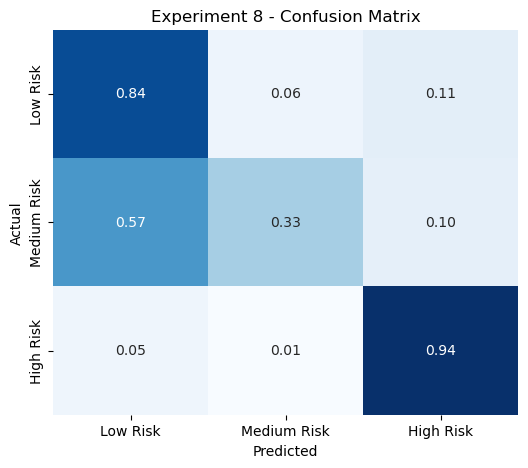

array([[0.83686577, 0.0581246 , 0.10500963],
       [0.56937799, 0.33492823, 0.09569378],
       [0.05317578, 0.00886263, 0.9379616 ]])

In [140]:
plot_confusion_matrix(
    experiment8['valid_y'],
    experiment8['pred_classes'],
    title = 'Experiment 8 - Confusion Matrix',
    class_labels=['Low Risk', 'Medium Risk', 'High Risk'],
    normalize=True
)